<a href="https://colab.research.google.com/github/Xenom38/CECS-101-Digital-Portfolio/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

NumPy: Maintain's/handles, different types of arrays of mathmatical calcualtions.
Mataplotlib: creates graphs & plots
Seaborn: Makes statistical graphs easier & cleaner/neatly looking.
from sklearn.model_selection import train_test_split: splits my dataset into training data & testing data.
from sklearn.linear_model import LinearRegression: Imports the linear Regression model in to order to learn the different relationship between your input & output variables.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import drive: this imports Colab Google Drive connection feature
drive.mount('/content/drive'):It's asking me to authorize access to my google drive then it makes my drive available inside colab.
/content/drive:After it mounts, my normal drive files are usually done inside
this code lets colab notebook read files & save them to my drive.

In [ ]:
import pandas as pd

file_path = '/content/finance_data.csv'  # Updated path to load from /content/
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully!


,year,quarter,company_id,sector,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
0,2000,1,Company_1,Finance,2.198686e+08,0.04,9755484.56,36.15,3.71,1.42,0.01,2.363830e+09
1,2000,1,Company_2,Consumer Goods,3.298028e+08,0.06,18814148.79,54.22,2.88,1.71,0.01,3.956767e+09
2,2000,1,Company_3,Finance,4.397371e+08,0.07,30660094.32,72.29,2.36,1.66,0.03,3.633502e+09
3,2000,1,Company_4,Energy,5.496714e+08,0.08,45293321.16,90.37,2.00,1.07,0.05,3.833839e+09
4,2000,1,Company_5,Manufacturing,6.596057e+08,0.10,62713829.30,108.44,1.73,1.36,0.02,6.178690e+09


import pandas as pd: it is used to work w/datasets, tables, rows, & columns.
file_graph = '/content/finance_data.csv': this tells python where my dataset is specfically located. the file itself should be uploaded into colab - /content/ folder.
try: is telling the code to try runnning, but if something goes wrong, don't cut or stop the entire program w/ some type of malfunction.
df = pd.read_csv(file_path): This reads the CSV file & stores it to Pandas Dataframe named df= spreadsheet.
df.head(): shows the first 5 rows of your dataset so I can verify everything.
then comes in the error handling: except FileNotFoundError:
if python can not identify or find finance_data.csv: it will shoot a error message like file not found or to try again
except Exception as e: catches other alternative errors


### Data Overview

Let's start by looking at the general information about the DataFrame, including data types and non-null values, and then generate descriptive statistics.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            2500 non-null   int64  
 1   quarter         2500 non-null   int64  
 2   company_id      2500 non-null   object 
 3   sector          2500 non-null   object 
 4   revenue         2500 non-null   float64
 5   profit_margin   2500 non-null   float64
 6   profit          2500 non-null   float64
 7   stock_price     2500 non-null   float64
 8   pe_ratio        2500 non-null   float64
 9   debt_to_equity  2379 non-null   float64
 10  dividend_yield  2500 non-null   float64
 11  market_cap      2500 non-null   float64
dtypes: float64(8), int64(2), object(2)
memory usage: 234.5+ KB
None


print(): pretty much just tells python to display whatever is returned.
df.info(): shows things like-how many columns in the dataset, or how many columns there are, each columns name, each columns data type, inlcluding non-null values each column has, & an est on the memory the dataframe is using

In [ ]:
display(df.describe())

,year,quarter,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
count,2500.000000,2500.000000,2.500000e+03,2500.000000,2.500000e+03,2500.000000,2500.000000,2379.000000,2500.000000,2.500000e+03
mean,2012.000000,2.500000,2.658120e+09,0.373936,1.199423e+09,465.459628,0.741324,1.193817,0.020316,2.526694e+10
std,7.212545,1.118258,1.624470e+09,0.221228,1.129004e+09,283.374544,0.632146,0.403104,0.010457,2.104715e+10
min,2000.000000,1.000000,1.727128e+08,0.030000,7.817187e+06,28.840000,0.110000,0.000000,-0.010000,5.519471e+08
25%,2006.000000,1.750000,1.329516e+09,0.200000,2.821963e+08,230.660000,0.340000,0.920000,0.010000,9.483218e+09
50%,2012.000000,2.500000,2.409744e+09,0.340000,8.637113e+08,425.275000,0.530000,1.200000,0.020000,1.888935e+10
75%,2018.000000,3.250000,3.729541e+09,0.510000,1.803392e+09,650.585000,0.900000,1.460000,0.030000,3.583691e+10
max,2024.000000,4.000000,8.114111e+09,1.330000,6.382023e+09,1481.760000,6.260000,2.440000,0.050000,1.273142e+11


display(df.describe(): shows a statistical summary of the numerical columns
cout-the values present, mean- the averaeg, std-the standard deviation, or how spread out the values are, min-smallest value, 25%-first quartile,50%-median,75%-third quartile, max-largest value

### Missing Values Check

Next, let's check for any missing values in the dataset.

In [ ]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
year,0
quarter,0
company_id,0
sector,0
revenue,0
profit_margin,0
profit,0
stock_price,0
pe_ratio,0
debt_to_equity,121


print('Mising values per column:'):prints a label so you pretty much know what the next output means
display(df.isnull().sum()):df.isnull()-verifies each cell to see what is missing,.sum()-counts the missing value in each column,display()-shows the result neatly in colab

In [ ]:
df_cleaned = df.dropna()
print("DataFrame after removing rows with missing values:")
print(df_cleaned.info())

DataFrame after removing rows with missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 2379 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            2379 non-null   int64  
 1   quarter         2379 non-null   int64  
 2   company_id      2379 non-null   object 
 3   sector          2379 non-null   object 
 4   revenue         2379 non-null   float64
 5   profit_margin   2379 non-null   float64
 6   profit          2379 non-null   float64
 7   stock_price     2379 non-null   float64
 8   pe_ratio        2379 non-null   float64
 9   debt_to_equity  2379 non-null   float64
 10  dividend_yield  2379 non-null   float64
 11  market_cap      2379 non-null   float64
dtypes: float64(8), int64(2), object(2)
memory usage: 241.6+ KB
None


df_cleaned = df.dropna(): df.dropna()-removes rows that have at least one missing value
The cleaned dataset is saved as a new DataFrame called df_cleaned
My original df doesn't change
print("DataFrame after removing rows with missing values:"):prints a label
print(df_cleaned.info()): shows the neatly structured cleaned dataset, including the # of rows in each columns data set.

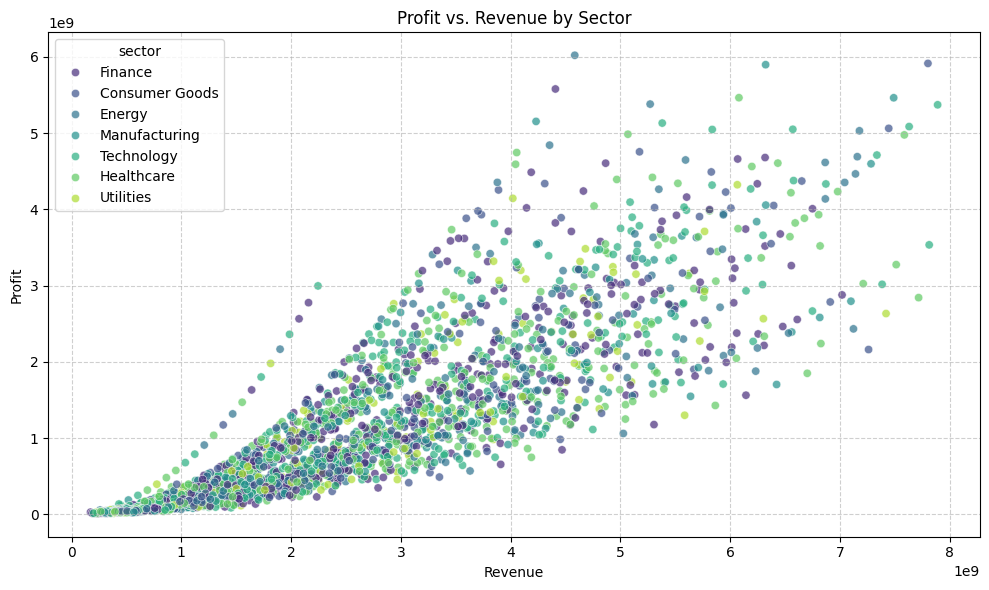

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='revenue', y='profit', hue='sector', palette='viridis', alpha=0.7)
plt.title('Profit vs. Revenue by Sector')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt: creates graphs & visuals/visualizations
import seaborn as sns:imports matplotlib & gives it the shorter name plt its used for things like Scatter plots, line graphs, labels, titles, & displaying figures.
import seaborn as sns: seaborn gives it a shorter name sns, but seaborn is built on top of matplotlib making the statistical graph easier to create.

### Correlation Matrix

Let's compute and visualize the correlation matrix to understand the relationships between numerical features.

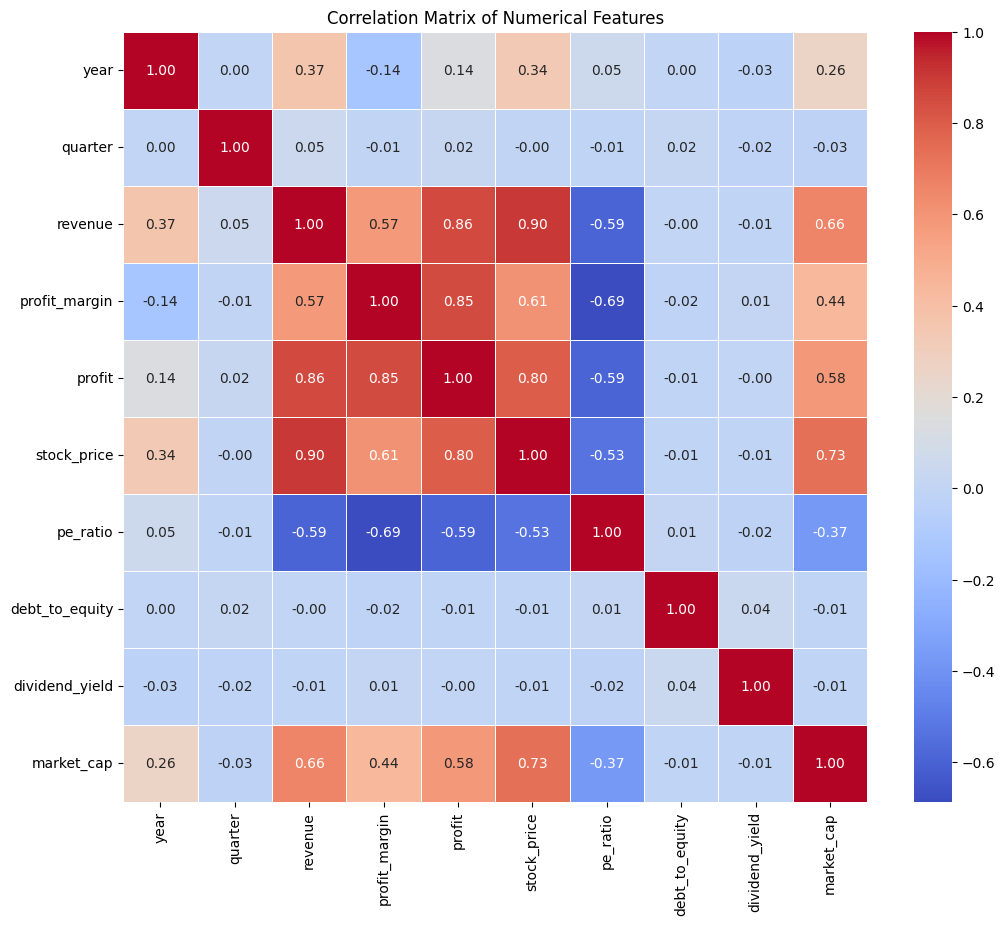

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df_cleaned.select_dtypes(include=['float64', 'int64']).corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Seaborn as sns: used for cleaner statistical graphs
matplotlib.pylot as plt: used for creating & customizing plots.-brings in seaborn for making graphs. Import matplotlib.pylot as plt: brings in matplotlib for showing & editing graphs. correlation_matrix= ...: verifies hwo strongly the # columns are related/similar to each other. plt.figure(figsize=(12, 10)): sets the graph size. sns.heatmap(...): creates teh colored heatmap. annot=True: shows the #'s inside the boxes. cmap='coolwarm': chooses the heatmap colors.fmt='.2f':shows #'s with 2 decimal places. linewidths=.5:adds thin lines in betweeen the boxes.plt.title(...):adds the graph title. plt.show():displays the graph.

The heatmap visually represents the correlation coefficients between all pairs of numerical columns. Values close to 1 (bright red) indicate a strong positive correlation, while values close to -1 (bright blue) indicate a strong negative correlation. Values close to 0 (white/light colors) suggest a weak or no linear correlation.

### Machine Learning Model: Predicting Stock Price

Now, let's build a machine learning model to predict the `stock_price` based on other financial indicators. We will use a Linear Regression model for this task.

In [ ]:
# Define features (X) and target (y)
# Exclude 'company_id' as it's an identifier, 'stock_price' as it's the target,
# and 'market_cap' due to its very high correlation with stock_price (potential multicollinearity/data leakage).
features = ['year', 'quarter', 'revenue', 'profit_margin', 'profit', 'pe_ratio', 'debt_to_equity', 'dividend_yield', 'sector']
X = df_cleaned[features]
y = df_cleaned['stock_price']

# One-hot encode the 'sector' column
X = pd.get_dummies(X, columns=['sector'], drop_first=True)

# Display the first few rows of the processed features
print("Processed Features (X) head:")
display(X.head())

# Display the first few rows of the target variable
print("Target Variable (y) head:")
display(y.head())

Processed Features (X) head:


,year,quarter,revenue,profit_margin,profit,pe_ratio,debt_to_equity,dividend_yield,sector_Energy,sector_Finance,sector_Healthcare,sector_Manufacturing,sector_Technology,sector_Utilities
0,2000,1,2.198686e+08,0.04,9755484.56,3.71,1.42,0.01,False,True,False,False,False,False
1,2000,1,3.298028e+08,0.06,18814148.79,2.88,1.71,0.01,False,False,False,False,False,False
2,2000,1,4.397371e+08,0.07,30660094.32,2.36,1.66,0.03,False,True,False,False,False,False
3,2000,1,5.496714e+08,0.08,45293321.16,2.00,1.07,0.05,True,False,False,False,False,False
4,2000,1,6.596057e+08,0.10,62713829.30,1.73,1.36,0.02,False,False,False,True,False,False


Target Variable (y) head:


,stock_price
0,36.15
1,54.22
2,72.29
3,90.37
4,108.44


features = [...]:picks the columns the model will use to make predicitions.
X = df_cleaned[features]:puts the selected columns into x. y = df_cleaned['stock_price']:;sets stock_price as the thing the model is trying to predict.pd.get_dummies(...): converts the sector column from words like "technology" or "finance" into #'s the model can understand.drop_first=True: removes one extra category so the model doesn't get duplicate information. print("Processed Features..."):prints a label.display(X.head()):shows the first 5 rows of the input data. print("Target Variable..."):prints another label. display(y.head()):shows the first 5 stock prices.

### Splitting Data into Training and Testing Sets

We'll split our dataset into training and testing sets to evaluate the model's performance on unseen data. A common split is 80% for training and 20% for testing.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1903 samples
Testing set size: 476 samples


train_test_split(...):splits your data into training data & testing data. X_train:input data used to train the model. X_test: input data used to test the model.y_train:correct stock prices used during training. y_test:correct stock prices used to check the model afterward.test_size=0.2: uses 20% for testing & 80% for training.
random_state=42: makes the split stay the same everytime you run the code.X_train.shape[0]: counts how many training rows you have. X_test.shape[0]: counts how many testing rows that I have. print(...):displays those amounts

### Training the Linear Regression Model

Now, we'll initialize and train a Linear Regression model on the training data.

In [ ]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


model = LinearRegression(): creates a new linear regression model. model.fit(X_train, y_train): trains the model using your training data. X_train:the information the model learns from. y_train:the correct stock prices the model uses to learn the relationship.print(...):displays a message confirming the training step finished.

### Model Evaluation

After training, we'll evaluate the model's performance on the test set using metrics such as Mean Squared Error (MSE) and R-squared (R2).

### Visualization of Predicted Stock Prices for New Data

Let's visualize the distribution of the predicted stock prices for the randomly generated data points to understand their range and frequency.

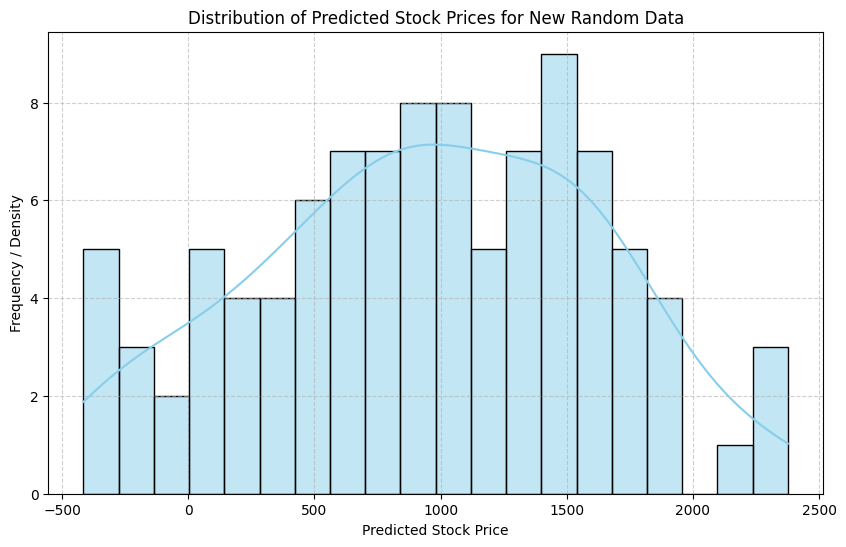

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_new_pred, kde=True, bins=20, color='skyblue')
plt.title('Distribution of Predicted Stock Prices for New Random Data')
plt.xlabel('Predicted Stock Price')
plt.ylabel('Frequency / Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

import matplotlib.pylot as plt: brings in Matplotlib for making graphs. import seaborn as sns: brings in Seaborn for easier graphing. plt.figure(figsize=(10,6)):sets the graph size. sns.histplot(y_new_pred, ...):makes a histogram of the predicted stock prices. y_new_pred:contains the stock prices your model predicted.kde=True:adds a smooth curve showing the overall shape of the predictions.bins=20:splits the predictions into 20 groups/bars. color='skyblue':makes the bars light blue.plt.title(...):adds the graph title.plt.xlabel(...):labels the bottom axis as predicted stock price.plt.ylabel(...):labels the side axis as frequency/density. plt.grid(...):adds the light dashed grid lines.plt.show():displays the graph.

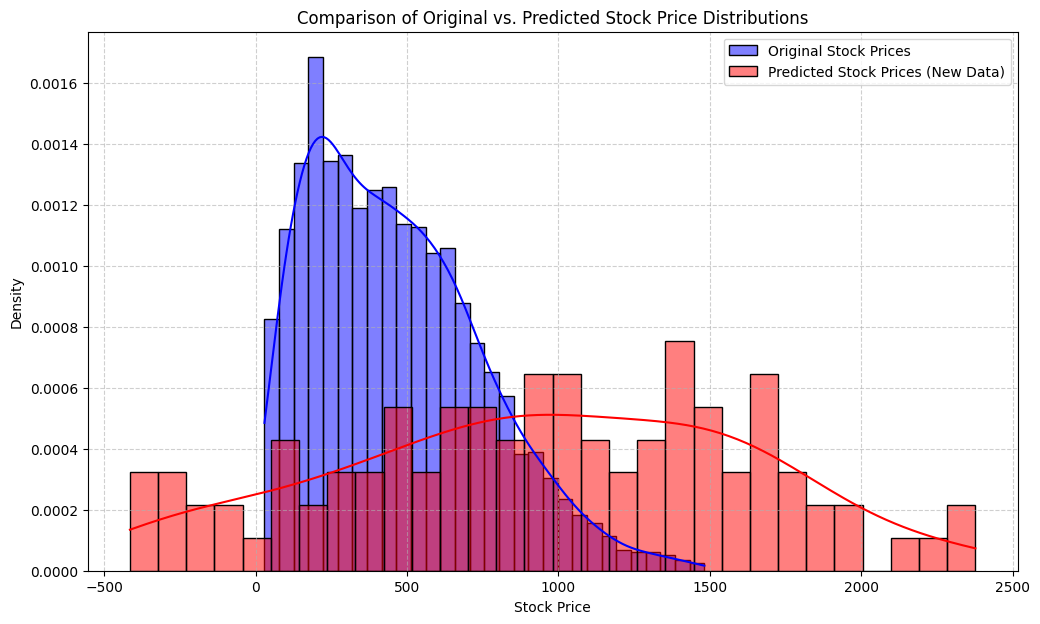

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(df_cleaned['stock_price'], color='blue', label='Original Stock Prices', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot(y_new_pred, color='red', label='Predicted Stock Prices (New Data)', kde=True, stat='density', alpha=0.5, bins=30)
plt.title('Comparison of Original vs. Predicted Stock Price Distributions')
plt.xlabel('Stock Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(12, 7)):makes the graph area & set its size. sns.histoplot(df_cleaned['stock_price'], ...):makes a histogram for the original stock prices from your dataset. color='blue':makes the original data blue. label='Original Stock Prices': gives that graph a name for the legend. kde=True: adds a smooth curve. stat='density':shows density instead of raw counts. alpha=0.5:makes it partly see-through.bins=30:splits the data into 30 bars.sns.histplot(y_new_pred, ...):makes another histogram for the predicted stock prices. color='red':makes the predicted data red.label='Predicted Stock Prices (New Data)':names it in legend.the other settings do the same exact thing above. plt.title(...):adds the title.plt.xlabel(...):adds the title.plt.xlabel('Stock Price'):labels the bottom axis.plt.ylabel('Density'):labels the side axis. plt.legend():shows which color is original & which is predicted. plt.grid(...):adds light grid lines. plt.show():displays the graph

### Generate 100 Random Data Points for Prediction

We will now generate 100 synthetic data points to test our trained model. The values for each feature will be randomly generated within the observed ranges from the `df_cleaned` dataset, and we'll ensure the 'sector' column is handled correctly with one-hot encoding.

In [ ]:
# Get the list of original numerical features (excluding target and company_id, market_cap)
numerical_features = ['year', 'quarter', 'revenue', 'profit_margin', 'profit', 'pe_ratio', 'debt_to_equity', 'dividend_yield']

# Create an empty DataFrame for new data points
X_new = pd.DataFrame()

# Generate random data for numerical features within their observed ranges
for col in numerical_features:
    min_val = df_cleaned[col].min()
    max_val = df_cleaned[col].max()
    if col == 'year':
        X_new[col] = np.random.randint(min_val, max_val + 1, 100) # +1 for randint upper bound exclusivity
    elif col == 'quarter':
        X_new[col] = np.random.randint(1, 5, 100) # Quarters are 1, 2, 3, 4
    else:
        X_new[col] = np.random.uniform(min_val, max_val, 100)

# Handle the one-hot encoded 'sector' features
sector_cols = [col for col in X.columns if col.startswith('sector_')]

# Initialize all sector columns to 0
for col in sector_cols:
    X_new[col] = 0

# Randomly select one sector to be '1' for each of the 100 new data points
random_sectors = np.random.choice(sector_cols, 100)
for i, sector in enumerate(random_sectors):
    X_new.loc[i, sector] = 1

# Ensure the order of columns in X_new matches X (the training data)
X_new = X_new[X.columns]

print("Generated 100 new random data points (features):")
display(X_new.head())

# Predict stock prices for the new data points
y_new_pred = model.predict(X_new)

print("\nPredicted Stock Prices for the new data points (first 5):")
display(pd.Series(y_new_pred).head())


Generated 100 new random data points (features):


,year,quarter,revenue,profit_margin,profit,pe_ratio,debt_to_equity,dividend_yield,sector_Energy,sector_Finance,sector_Healthcare,sector_Manufacturing,sector_Technology,sector_Utilities
0,2007,1,3.610452e+09,0.443824,3.776933e+09,1.456609,1.266531,0.041175,0,0,0,0,1,0
1,2005,4,2.605657e+09,0.053676,2.593082e+09,1.286942,2.048675,0.046727,0,0,1,0,0,0
2,2017,3,2.572806e+08,0.316068,4.051162e+09,5.117139,1.572037,0.024483,0,1,0,0,0,0
3,2020,4,6.492602e+09,0.324998,1.178418e+09,5.676648,1.134891,0.036153,0,0,0,0,1,0
4,2023,3,5.593018e+08,0.277669,2.750804e+09,1.934432,0.661713,0.007493,0,0,0,1,0,0



Predicted Stock Prices for the new data points (first 5):


,0
0,405.496123
1,36.417402
2,-89.086570
3,1688.810962
4,-126.967398


numerical_feature = [...]: lists the number based columns you want to create new fake data for. X_new = pd.DataFrame():creates an empty table for the new data.for col in numerical_features: goes through each feature one at a time. .min() / .max(): finds the smallest & largest real values from your dataset. np.random.randint(...):creates random whole #'s for year & quarter. np.random.uniform(...):creates random decimal values for the other numerical columns. 100: creates 100 new fake data rows. sector_cols = [...]:finds all the sector columns created earlier by one-hot encoding. X_new[col] = 0:starts all sector columns at 0.np.random.choice(...):randomly chooses a sector for each new row. X_new.loc[i, sector] = 1: marks that chosen sector as 1. X_new = X_new[X.columns]: makes sure the new columns are in the exact same order as the training data. display(X_new.head())):shows the first 5 new fake rows. model.predict(X_new):predicts stock prices for all 100 new rows.y_new_pred:stores those predicted stock prices. display (pd.Series(y_new_pred).head()):shows/displays the first 5 predicions.

Mean Squared Error (MSE): 12522.20
R-squared (R2): 0.85


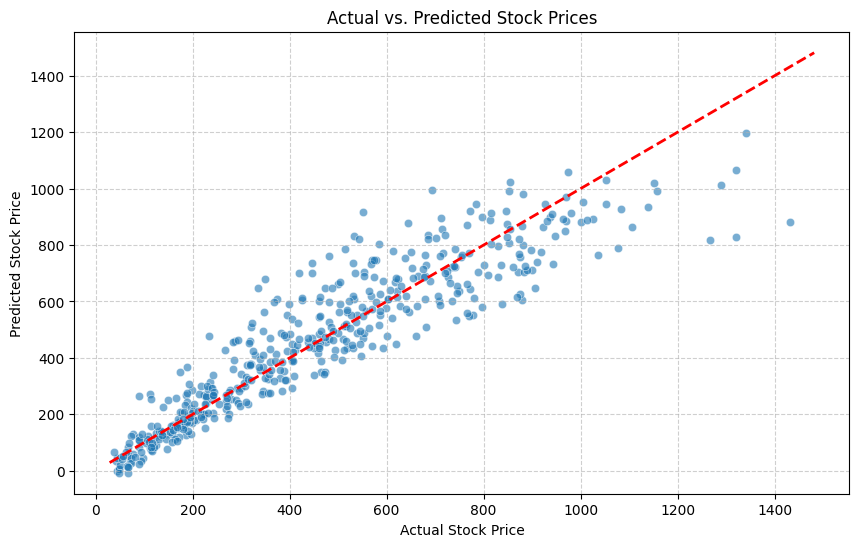

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2) # Line for perfect prediction
plt.title('Actual vs. Predicted Stock Prices')
plt.xlabel('Actual Stock Price')
plt.ylabel('Predicted Stock Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

y_pred = model.predict(X_test): uses the trained model to predict stock prices from the test data. mean_squared_error(y_test, y_pred):checks how far the predictions are from the real prices. Lower is way better.r2_score(y_test, y_pred): checks how well the model explains th real stock price data typically when its closer to 1 its better. print(...):displays the MSE & R^2 results. plt.figure(figsize=(10, 6)):sets the graph size. sns. scatterplot(x=y_test, y=y_pred, aplha=0.6):plots real prices against predicted prices. plt.plot(...): draws a reference line showing where perfect predictions would fall. plt.plot(...):draws a reference line showing where perfect predictions would fall.plt.title(...):adds the graph title. plt.xlabel(...):labels the actual price axis. plt.ylabel(...):labels the predicted-price axis. plt.grid(...):adds grid lines.plt.show:displays the graph